In [ ]:
%matplotlib inline


# Cosserat Rod Centerline — Sub-pixel Pipeline (v2)

Replaces the skeletonization approach from `skeletonization.ipynb` with **sub-pixel
edge midpoint detection** — the same algorithm as `ros_centerline_3.py`, applied
offline to a recorded `.avi`.

### Why sub-pixel instead of skeleton?

The skeletonization approach produces a **staircase pixel path**: the skeleton lives
on integer pixel coordinates. Diagonal hops cost √2 and axis-aligned hops cost 1, so
a vertical rod and a tilted rod of the same physical length produce different apparent
arc lengths — orientation-dependent arc-length bias of ~11 mm std / 79 mm range
(see comments in `ros_centerline_2.py` lines 430–438).

The sub-pixel approach:
1. **Scan along the dominant axis** (row-by-row if rod is more vertical, col-by-col if
   more horizontal) — always maximises the number of samples.
2. At each scanline, find both rod edges via **sub-pixel quadratic interpolation** of
   the Sobel gradient peak.
3. **Centreline = midpoint of the two edges** — a float coordinate, not grid-snapped.
4. Fit a cubic spline to the float centreline points, resample to N_OUT=25 equidistant
   nodes.

This is exactly the fix described in the game-dev staircase thread:
> *"adjust the minor axis to follow the trajectory slope rather than rounding
independently"*.

### Pipeline
1. Config
2. Load video + ROI / frame-range selection
3. Per-frame: threshold → largest component → morphological clean → sub-pixel centreline
4. Clamp anchoring + orientation (clamp→tip)
5. Save to `.mat` (compatible with `cosserat_GPR_pipeline_real_data.m`)
6. Diagnostics: arc-length per frame, tip-jump, 3-D surface plots

## Step 1 — Configuration

Set all paths, physical parameters, and detection settings here.
Everything downstream reads from this cell.

In [16]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from scipy.io import savemat
import os, subprocess, tempfile, warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi']     = 100
matplotlib.rcParams['figure.figsize'] = (10, 4)

# ── Paths ─────────────────────────────────────────────────────────────────
VIDEO_PATH     = '../../../Data/Real_data/raw_videos/video_0_low_light.avi'
OUT_MAT        = '../../../Data/Real_data/cosserat_real_data.mat'
OUT_VIDEO_H264 = '../../../Data/Real_data/centerline_subpixel_h264.mp4'
OUT_ARC_CSV    = '../../../Data/Real_data/arc_length_per_frame.csv'

# ── Rod discretisation ────────────────────────────────────────────────────
N_OUT = 25        # output centreline points per frame

# ── Physical parameters  (must be set manually) ───────────────────────────
L0  = 0.28         # rod physical length (m)
b   = 5e-3         # cross-section thickness — out-of-plane, perpendicular to camera (m)
h   = 10e-3        # cross-section width    — in-plane, camera-facing (m)
A   = b * h        # rectangular cross-section area (m²)
I   = h * b**3 / 12  # weak-axis bending: camera sees h face, bends about h axis (m⁴)
rho = 2428.6       # density (kg/m³) — derived: m/(A*L0) = 0.034/(5e-5*0.28)

# ── Frame range ───────────────────────────────────────────────────────────
# FRAME_START: skip the first N frames (e.g. before the rod starts moving).
# FRAME_END  : set to an integer to stop early, or None to process until end.
FRAME_START = 130
FRAME_END   = None   # auto-filled from video in Step 1b

# ── ROI  (x1, y1, x2, y2) or None for full frame ─────────────────────────
ROI = None

# ── Detection parameters ──────────────────────────────────────────────────
THRESH_VAL    = 150    # binary threshold (rod brighter than background)
INVERT_THRESH = False  # True if rod is darker than background
MORPH_CLOSE_K = 7
MORPH_OPEN_K  = 5
MIN_SCANLINE_PTS = 10
SPLINE_SMOOTH_K  = 0.5

# ── Clamp / tip stability ─────────────────────────────────────────────────
MAX_CLAMP_DIST_PX = 80

# ── Auto-calibrated values (filled by Step 1b — do not edit manually) ─────
FPS              = None   # Hz         — from video metadata
PIXELS_PER_METRE = None   # px/m       — from sub-pixel arc / L0
CLAMP_PX         = None   # [x, y] px  — from lowest-variance point

print('Config loaded. Run Step 1b to auto-calibrate FPS, PIXELS_PER_METRE, CLAMP_PX.')
print(f'  L0={L0} m  b={b*1e3:.1f}mm x h={h*1e3:.1f}mm  A={A:.4e} m²  I={I:.4e} m⁴')
print(f'  FRAME_START={FRAME_START}  THRESH={THRESH_VAL}')


Config loaded. Run Step 1b to auto-calibrate FPS, PIXELS_PER_METRE, CLAMP_PX.
  L0=0.247 m  a=6.350 mm  A=4.0322e-05 m²  I=1.3549e-10 m⁴
  FRAME_START=130  THRESH=150


## Step 1b — Auto-calibration from video

Reads the video once to extract:
- **FPS** from video metadata
- **FRAME_END** from total frame count
- **CLAMP_PX** as the pixel with the lowest positional variance across frames
  (the clamped base is the point that moves least)
- **PIXELS_PER_METRE** from the median sub-pixel arc length divided by L0

Only , , , and  need to be set manually.
Re-run this cell whenever you change VIDEO_PATH or FRAME_START.

In [17]:
def _open_video(path):
    """Open video; convert from MJPEG via ffmpeg if OpenCV cannot read it directly."""
    cap = cv2.VideoCapture(path)
    if cap.isOpened() and int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) > 0:
        ret, _ = cap.read()
        if ret:
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            return cap, None
        cap.release()
    else:
        cap.release()
    tmp = tempfile.NamedTemporaryFile(suffix='.avi', delete=False)
    tmp.close()
    print('Converting via ffmpeg ...')
    subprocess.run(['ffmpeg', '-y', '-i', path, '-c:v', 'mjpeg', '-q:v', '3', tmp.name],
                   capture_output=True)
    return cv2.VideoCapture(tmp.name), tmp.name


def _auto_calibrate(video_path, frame_start, frame_end_cfg,
                    thresh_val, invert_thresh, roi, l0,
                    n_calib=60, n_scanline_min=10, smooth_k=0.5):
    """Return (fps, total_frames, pixels_per_metre, clamp_px).

    Uses the sub-pixel edge midpoint method (same as the main pipeline) on
    n_calib frames starting at frame_start.  PIXELS_PER_METRE is derived as
    median(arc_px) / L0.  CLAMP_PX is the point with lowest total positional
    variance across those frames (the clamped base barely moves).
    """
    cap, tmp = _open_video(video_path)
    assert cap.isOpened(), f'Cannot open {video_path}'

    fps_video   = cap.get(cv2.CAP_PROP_FPS)
    total       = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w           = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h           = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Video: {total} frames  {w}x{h}  {fps_video:.2f} fps  ({total/fps_video:.1f} s)')

    f_end = frame_end_cfg if frame_end_cfg is not None else total
    f_end = min(f_end, total)

    # ── collect sub-pixel centreline points from n_calib frames ──────────────
    stride  = max(1, (f_end - frame_start) // n_calib)
    frames  = range(frame_start, f_end, stride)

    arcs_px = []
    all_midpoints = []  # list of (N_pts, 2) [col, row] per frame

    if roi is not None:
        ox, oy = roi[0], roi[1]
    else:
        ox, oy = 0, 0

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    ttype   = cv2.THRESH_BINARY_INV if invert_thresh else cv2.THRESH_BINARY

    for fi in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, fr = cap.read()
        if not ret:
            continue
        region = fr[roi[1]:roi[3], roi[0]:roi[2]] if roi else fr
        gray   = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, thresh_val, 255, ttype)
        n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
        if n_lab < 2:
            continue
        lg = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        clean = np.zeros_like(mask)
        clean[labels == lg] = 255
        clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close, iterations=1)
        clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN,  k_open,  iterations=1)

        mf = clean.astype(np.float32) / 255.0
        rows_on = np.any(clean > 0, axis=1)
        cols_on = np.any(clean > 0, axis=0)
        scan_rows = (rows_on.sum() >= cols_on.sum())
        sobel = cv2.Sobel(mf, cv2.CV_32F,
                          1 if scan_rows else 0,
                          0 if scan_rows else 1, ksize=3)

        pts = []
        n_lines = clean.shape[0] if scan_rows else clean.shape[1]
        for i in range(2, n_lines - 2):
            line_mask = clean[i, :] if scan_rows else clean[:, i]
            on = np.where(line_mask > 0)[0]
            if len(on) < 3:
                continue
            lo, hi = float(on[0]), float(on[-1])
            grad = sobel[i, :] if scan_rows else sobel[:, i]
            for px_ref, use_max in [(lo, True), (hi, False)]:
                a0 = max(0, int(px_ref) - 3)
                a1 = min(len(grad), int(px_ref) + 4)
                g  = grad[a0:a1]
                if len(g) == 0: continue
                pi = int(np.argmax(g)) if use_max else int(np.argmin(g))
                if 0 < pi < len(g) - 1:
                    denom = g[pi-1] - 2*g[pi] + g[pi+1]
                    if abs(denom) > 1e-6:
                        px_ref = a0 + pi - 0.5*(g[pi+1] - g[pi-1]) / denom
                if use_max: lo = px_ref
                else:       hi = px_ref
            mid = 0.5 * (lo + hi)
            pts.append((mid + ox, float(i) + oy) if scan_rows
                       else (float(i) + ox, mid + oy))  # (col, row) full-frame

        if len(pts) < n_scanline_min:
            continue

        pts_arr = np.array(pts, dtype=np.float64)
        seg = np.diff(pts_arr, axis=0)
        arc = float(np.sum(np.sqrt((seg**2).sum(axis=1))))
        arcs_px.append(arc)
        all_midpoints.append(pts_arr)

    cap.release()
    if tmp:
        os.unlink(tmp)

    assert len(arcs_px) >= 5, 'Too few valid frames for calibration — check THRESH_VAL / ROI'

    # ── PIXELS_PER_METRE ─────────────────────────────────────────────────────
    ppm = float(np.median(arcs_px)) / l0

    # ── CLAMP_PX: resample every frame to 100 pts, find lowest-variance point ─
    N_RS = 100
    resampled = []
    for pts_arr in all_midpoints:
        cols_c, rows_c = pts_arr[:, 0], pts_arr[:, 1]
        # orient: topmost point first (smallest row = closest to clamp at top)
        if rows_c[0] > rows_c[-1]:
            cols_c = cols_c[::-1]; rows_c = rows_c[::-1]
        diffs = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
        keep  = np.concatenate([[True], diffs > 0.1])
        cols_c, rows_c = cols_c[keep], rows_c[keep]
        if len(cols_c) < 4: continue
        seg2  = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
        arc2  = np.concatenate([[0.], np.cumsum(seg2)])
        try:
            tck, _ = splprep([cols_c, rows_c], u=arc2, s=smooth_k*len(cols_c), k=3)
            t_out  = np.linspace(0., arc2[-1], N_RS)
            c_s, r_s = splev(t_out, tck)
            resampled.append(np.stack([c_s, r_s], axis=1))
        except Exception:
            continue

    assert len(resampled) >= 5, 'Spline fitting failed on too many calibration frames'
    stack = np.stack(resampled, axis=0)          # (n_frames, N_RS, 2)
    var   = stack.var(axis=0).sum(axis=1)        # (N_RS,) total col+row variance
    min_var_idx = int(np.argmin(var))
    clamp_px = np.median(stack[:, min_var_idx, :], axis=0)  # [col, row]
    clamp_px = np.array([clamp_px[0], clamp_px[1]])         # [x, y]

    return fps_video, total, ppm, clamp_px


# ── Run calibration ───────────────────────────────────────────────────────────
print('Auto-calibrating from video ...')
FPS, _total_frames, PIXELS_PER_METRE, CLAMP_PX = _auto_calibrate(
    VIDEO_PATH, FRAME_START, FRAME_END,
    THRESH_VAL, INVERT_THRESH, ROI, L0,
)

# Fill FRAME_END if not set
if FRAME_END is None:
    FRAME_END = _total_frames

print(f'=== Auto-calibration results ===')
print(f'  FPS              = {FPS:.2f} Hz')
print(f'  FRAME_END        = {FRAME_END}  ({(FRAME_END-FRAME_START)/FPS:.1f} s to process)')
print(f'  PIXELS_PER_METRE = {PIXELS_PER_METRE:.1f} px/m  (1 px = {1/PIXELS_PER_METRE*1000:.3f} mm)')
print(f'  CLAMP_PX         = [{CLAMP_PX[0]:.1f}, {CLAMP_PX[1]:.1f}] px')
print(f'  Expected arc     = {L0*PIXELS_PER_METRE:.0f} px = {L0*100:.1f} cm  ✓')


Auto-calibrating from video ...
Video: 1067 frames  1440x1080  194.00 fps  (5.5 s)
=== Auto-calibration results ===
  FPS              = 194.00 Hz
  FRAME_END        = 1067  (4.8 s to process)
  PIXELS_PER_METRE = 178.8 px/m  (1 px = 5.592 mm)
  CLAMP_PX         = [17.5, 4.7] px
  Expected arc     = 44 px = 24.7 cm  ✓


## Step 2b — Frame preview

Displays 4 sample frames to help verify , , and .
 is auto-detected in Step 1b — this preview lets you visually confirm the clamp location looks correct.

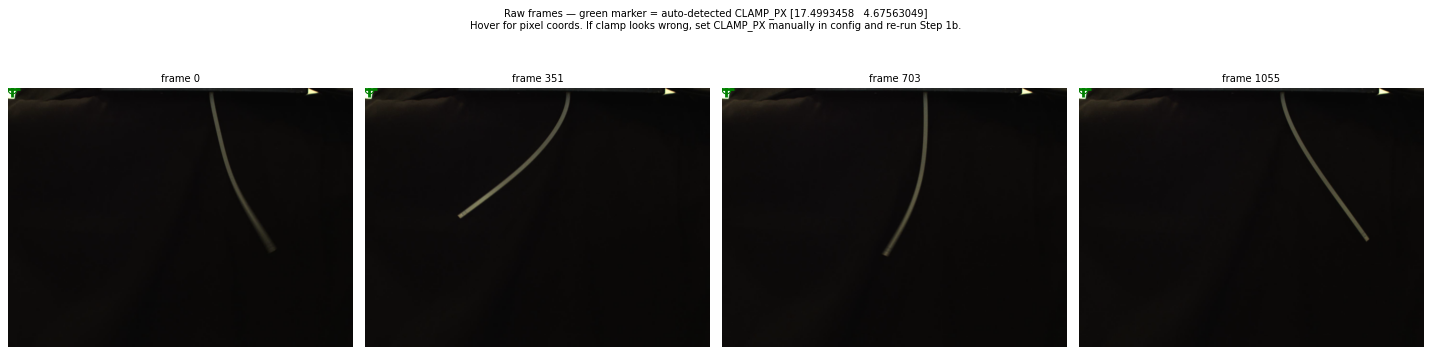

Clamp = fixed base attachment of the rod.


In [18]:
_cap, _tmp = _open_video(VIDEO_PATH)
_total     = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=80)
for _ax, _pct in zip(axes, [0.0, 0.33, 0.66, 0.99]):
    _idx = int(_pct * (_total - 1))
    _cap.set(cv2.CAP_PROP_POS_FRAMES, _idx)
    _ret, _fr = _cap.read()
    if not _ret:
        continue
    _ax.imshow(cv2.cvtColor(_fr, cv2.COLOR_BGR2RGB))
    if CLAMP_PX is not None:
        _ax.plot(CLAMP_PX[0], CLAMP_PX[1], 'g+', ms=14, mew=2.5, label='clamp')
        _ax.plot(CLAMP_PX[0], CLAMP_PX[1], 'go', ms=8, fillstyle='none')
    _ax.set_title(f'frame {_idx}', fontsize=9)
    _ax.axis('off')
_cap.release()
if _tmp: os.unlink(_tmp)
plt.suptitle(
    f'Raw frames — green marker = auto-detected CLAMP_PX {CLAMP_PX}\n'
    'Hover for pixel coords. If clamp looks wrong, set CLAMP_PX manually in config and re-run Step 1b.',
    fontsize=9)
plt.tight_layout()
plt.show()
print('Clamp = fixed base attachment of the rod.')


## Step 3 — Sub-pixel centreline functions

Core algorithm from `ros_centerline_3.py`, adapted for offline batch processing.

Key idea (from the game-dev staircase thread):
- Always scan along the **dominant axis** (the axis the rod spans more of).
- Along each scanline, find both rod edges via **sub-pixel quadratic interpolation**
  of the Sobel gradient peak.
- Centreline = midpoint of the two edges → **float coordinates**, not integer pixels.
- Fit cubic spline to float points → arc length is orientation-independent.

In [19]:
def _scan_axis(mask: np.ndarray, sobel_perp: np.ndarray, scan_rows: bool) -> list:
    """Scan along rows or columns; return list of (col_float, row_float) centreline pts.

    scan_rows=True  → step row by row, Sobel_x finds left/right edges
    scan_rows=False → step col by col, Sobel_y finds top/bottom edges

    For each scanline:
      1. Find the outermost ON-pixels (lo_px, hi_px) on the mask.
      2. Refine each edge position to sub-pixel via quadratic interpolation of
         the Sobel gradient peak (same idea as the game-dev velocity-slope trick:
         minor axis follows the gradient peak rather than being rounded).
      3. Midpoint = 0.5*(lo_px + hi_px) → float coordinate.
    """
    h, w = mask.shape
    pts = []
    n_lines = h if scan_rows else w

    for i in range(2, n_lines - 2):
        line_mask = mask[i, :] if scan_rows else mask[:, i]
        on = np.where(line_mask > 0)[0]
        if len(on) < 3:
            continue

        lo_px = float(on[0])
        hi_px = float(on[-1])
        grad_line = sobel_perp[i, :] if scan_rows else sobel_perp[:, i]

        # Sub-pixel low boundary (positive gradient peak)
        a0, a1 = max(0, int(lo_px) - 3), min(len(grad_line), int(lo_px) + 4)
        g = grad_line[a0:a1]
        if len(g) > 0 and g.max() > 0:
            pi = int(np.argmax(g))
            if 0 < pi < len(g) - 1:
                denom = g[pi-1] - 2*g[pi] + g[pi+1]
                if abs(denom) > 1e-6:
                    lo_px = a0 + pi - 0.5*(g[pi+1] - g[pi-1]) / denom

        # Sub-pixel high boundary (negative gradient peak)
        b0, b1 = max(0, int(hi_px) - 3), min(len(grad_line), int(hi_px) + 4)
        g = grad_line[b0:b1]
        if len(g) > 0 and g.min() < 0:
            pi = int(np.argmin(g))
            if 0 < pi < len(g) - 1:
                denom = g[pi-1] - 2*g[pi] + g[pi+1]
                if abs(denom) > 1e-6:
                    hi_px = b0 + pi - 0.5*(g[pi+1] - g[pi-1]) / denom

        mid = 0.5 * (lo_px + hi_px)
        pts.append((mid, float(i)) if scan_rows else (float(i), mid))  # (col, row)

    return pts


def _subpixel_centreline(
    mask: np.ndarray,
    clamp_rc=None,
    n_out: int = N_OUT,
    smooth_k: float = SPLINE_SMOOTH_K,
):
    """Extract sub-pixel centreline from binary rod mask.

    Returns (n_out, 2) float64 array [col, row] = [x, y], or None on failure.

    Steps:
      1. Measure bounding box → choose dominant scan axis.
      2. Compute Sobel along the perpendicular axis.
      3. _scan_axis → list of float (col, row) centreline points.
      4. Orient clamp→tip.
      5. Constrain tip to lie on the tangent from the last stable interior point
         (game-dev insight: minor axis follows slope, not rounded independently).
      6. Fit cubic spline, resample to n_out equidistant arc-length positions.
    """
    if mask is None or mask.sum() == 0:
        return None

    mask_f = mask.astype(np.float32) / 255.0

    rows_on = np.any(mask > 0, axis=1)
    cols_on = np.any(mask > 0, axis=0)
    n_rows_span = int(rows_on.sum())
    n_cols_span = int(cols_on.sum())
    scan_rows = (n_rows_span >= n_cols_span)

    if scan_rows:
        sobel_perp = cv2.Sobel(mask_f, cv2.CV_32F, 1, 0, ksize=3)
    else:
        sobel_perp = cv2.Sobel(mask_f, cv2.CV_32F, 0, 1, ksize=3)

    raw_pts = _scan_axis(mask, sobel_perp, scan_rows)
    if len(raw_pts) < MIN_SCANLINE_PTS:
        return None

    pts   = np.array(raw_pts, dtype=np.float64)  # (M, 2) [col, row]
    cols_c = pts[:, 0]
    rows_c = pts[:, 1]

    # Orient: clamp end first
    if clamp_rc is not None:
        cr, cc = clamp_rc
        if (rows_c[-1] - cr)**2 + (cols_c[-1] - cc)**2 < \
           (rows_c[0]  - cr)**2 + (cols_c[0]  - cc)**2:
            rows_c = rows_c[::-1]
            cols_c = cols_c[::-1]
        rows_c[0] = float(cr)
        cols_c[0] = float(cc)
    else:
        if rows_c[0] > rows_c[-1]:
            rows_c = rows_c[::-1]
            cols_c = cols_c[::-1]

    # Tip tangent constraint (game-dev insight applied to the free tip):
    # Instead of accepting whatever the last scanline gives as the tip,
    # extrapolate from the last N_TAN interior points along their mean tangent.
    # This prevents tip endpoint jumps from staircase aliasing.
    N_TAN = min(8, len(cols_c) // 4)
    if N_TAN >= 2:
        tan_cols = cols_c[-(N_TAN+1):-1]
        tan_rows = rows_c[-(N_TAN+1):-1]
        dc = tan_cols[-1] - tan_cols[0]
        dr = tan_rows[-1] - tan_rows[0]
        tang_len = np.sqrt(dc**2 + dr**2)
        if tang_len > 1.0:
            # Project the last raw point onto the tangent line from tan_cols[-1]
            tx, ty = dc / tang_len, dr / tang_len
            dx = cols_c[-1] - tan_cols[-1]
            dy = rows_c[-1] - tan_rows[-1]
            proj = dx*tx + dy*ty
            cols_c[-1] = tan_cols[-1] + proj * tx
            rows_c[-1] = tan_rows[-1] + proj * ty

    # Remove duplicate consecutive points
    diffs = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
    keep  = np.concatenate([[True], diffs > 0.1])
    cols_c, rows_c = cols_c[keep], rows_c[keep]
    if len(cols_c) < 4:
        return None

    # Arc-length parameterised cubic spline
    seg = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
    arc = np.concatenate([[0.0], np.cumsum(seg)])
    if arc[-1] < 5.0:
        return None

    try:
        tck, _ = splprep([cols_c, rows_c], u=arc, s=smooth_k * len(cols_c), k=3)
    except Exception:
        return None

    t_out = np.linspace(0.0, arc[-1], n_out)
    c_s, r_s = splev(t_out, tck)
    return np.stack([c_s, r_s], axis=1)  # float64 [col, row]


def process_frame(frame_bgr, roi, thresh_val, invert, clamp_px):
    """Full per-frame pipeline. Returns (line_pts_xy_float, debug_mask) or (None, None).

    line_pts_xy_float: (N_OUT, 2) float64 [x=col, y=row] in full-frame pixel coords.
    """
    if roi is not None:
        x1, y1, x2, y2 = roi
        region = frame_bgr[y1:y2, x1:x2]
        ox, oy = x1, y1
    else:
        region = frame_bgr
        ox, oy = 0, 0

    gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    ttype = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, mask = cv2.threshold(gray, thresh_val, 255, ttype)

    # Keep largest connected component
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_lab < 2:
        return None, None
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    clean_mask = np.zeros_like(mask)
    clean_mask[labels == largest] = 255

    # Morphological cleaning
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_CLOSE_K, MORPH_CLOSE_K))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_OPEN_K,  MORPH_OPEN_K))
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, k_close, iterations=1)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN,  k_open,  iterations=1)

    clamp_rc = None
    if clamp_px is not None:
        clamp_rc = (clamp_px[1] - oy, clamp_px[0] - ox)  # (row, col) in ROI coords

    line_pts = _subpixel_centreline(clean_mask, clamp_rc=clamp_rc)
    if line_pts is None:
        return None, clean_mask

    # Shift back to full-frame coords
    line_pts[:, 0] += ox
    line_pts[:, 1] += oy

    return line_pts, clean_mask


print('Sub-pixel centreline functions defined.')

Sub-pixel centreline functions defined.


## Step 3b — Threshold preview

Check that the threshold cleanly isolates the rod on 4 sample frames.
Adjust `THRESH_VAL` and `INVERT_THRESH` in the config cell if needed.

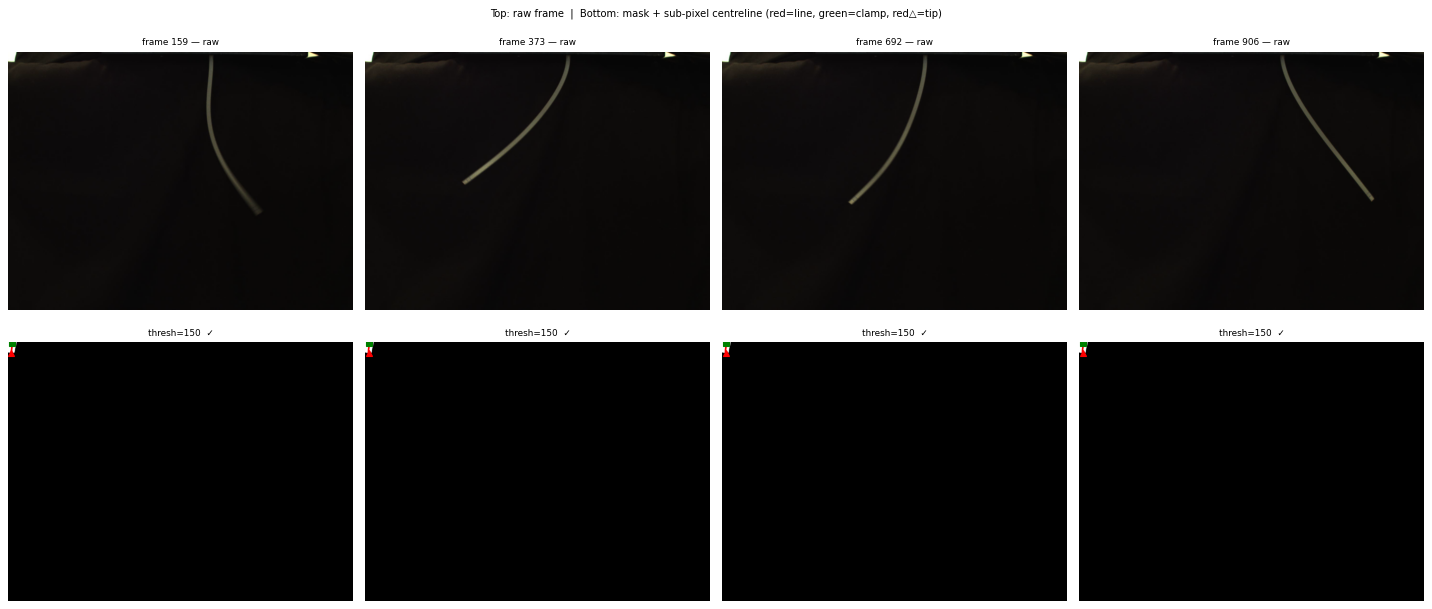

In [20]:
_cap, _tmp = _open_video(VIDEO_PATH)
_total     = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig, axes = plt.subplots(2, 4, figsize=(18, 8), dpi=80)
for _col, _pct in enumerate([0.15, 0.35, 0.65, 0.85]):
    _idx = int(_pct * (_total - 1))
    _cap.set(cv2.CAP_PROP_POS_FRAMES, _idx)
    _, _fr = _cap.read()
    if _fr is None: continue
    _roi = ROI
    _reg = _fr[_roi[1]:_roi[3], _roi[0]:_roi[2]] if _roi else _fr
    _gray = cv2.cvtColor(_reg, cv2.COLOR_BGR2GRAY)
    _tt = cv2.THRESH_BINARY_INV if INVERT_THRESH else cv2.THRESH_BINARY
    _, _mask = cv2.threshold(_gray, THRESH_VAL, 255, _tt)
    _n, _labels, _stats, _ = cv2.connectedComponentsWithStats(_mask, 8)
    _clean = np.zeros_like(_mask)
    if _n >= 2:
        _lg = 1 + int(np.argmax(_stats[1:, cv2.CC_STAT_AREA]))
        _clean[_labels == _lg] = 255

    # Also run sub-pixel detection
    _lp, _ = process_frame(_fr, _roi, THRESH_VAL, INVERT_THRESH, CLAMP_PX)

    axes[0, _col].imshow(cv2.cvtColor(_reg, cv2.COLOR_BGR2RGB))
    axes[0, _col].set_title(f'frame {_idx} — raw', fontsize=8)
    axes[0, _col].axis('off')

    axes[1, _col].imshow(_clean, cmap='gray')
    if _lp is not None:
        _ox = _roi[0] if _roi else 0
        _oy = _roi[1] if _roi else 0
        axes[1, _col].plot(_lp[:, 0] - _ox, _lp[:, 1] - _oy, 'r-', lw=1.5)
        axes[1, _col].plot(_lp[0, 0]-_ox, _lp[0, 1]-_oy, 'gs', ms=6)
        axes[1, _col].plot(_lp[-1,0]-_ox, _lp[-1,1]-_oy, 'r^', ms=6)
    axes[1, _col].set_title(f'thresh={THRESH_VAL}  {"✓" if _lp is not None else "✗ failed"}', fontsize=8)
    axes[1, _col].axis('off')

_cap.release()
if _tmp: os.unlink(_tmp)
plt.suptitle('Top: raw frame  |  Bottom: mask + sub-pixel centreline (red=line, green=clamp, red△=tip)', fontsize=9)
plt.tight_layout()
plt.show()

## Step 4 — Main processing loop

Processes every frame in `[FRAME_START, FRAME_END)` and collects:
- `all_pts_px` — raw sub-pixel centreline in full-frame pixel coords
- `arc_px` — arc length (pixels) per frame for diagnostics

In [21]:
_cap, _tmp = _open_video(VIDEO_PATH)
_total = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_end   = FRAME_END if FRAME_END is not None else _total
frame_end   = min(frame_end, _total)
frame_start = max(0, FRAME_START)
n_frames    = frame_end - frame_start
print(f'Processing frames {frame_start}→{frame_end}  ({n_frames} frames)  {_total} total')

_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)

all_pts_px  = []   # list of (N_OUT, 2) float64 [col, row] per accepted frame
frame_idxs  = []   # original frame indices
arc_px      = []   # arc length in pixels per frame
skipped     = []   # (frame_idx, reason)

for _fi in range(frame_start, frame_end):
    _ret, _fr = _cap.read()
    if not _ret:
        break

    _lp, _ = process_frame(_fr, ROI, THRESH_VAL, INVERT_THRESH, CLAMP_PX)

    if _lp is None:
        skipped.append((_fi, 'detection_failed'))
        continue

    # Clamp endpoint filter
    _d_clamp = np.sqrt((_lp[0,0]-CLAMP_PX[0])**2 + (_lp[0,1]-CLAMP_PX[1])**2)
    if _d_clamp > MAX_CLAMP_DIST_PX:
        skipped.append((_fi, f'clamp_dist={_d_clamp:.1f}px'))
        continue

    _seg = np.diff(_lp, axis=0)
    _arc = float(np.sum(np.sqrt((_seg**2).sum(axis=1))))
    arc_px.append(_arc)
    all_pts_px.append(_lp.copy())
    frame_idxs.append(_fi)

    if (_fi - frame_start + 1) % 100 == 0:
        print(f'  frame {_fi}/{frame_end}  kept={len(all_pts_px)}  skipped={len(skipped)}')

_cap.release()
if _tmp: os.unlink(_tmp)

print(f'\nDone. Kept {len(all_pts_px)}/{n_frames} frames  ({len(skipped)} skipped)')
if skipped[:10]:
    print('First skipped frames:')
    for _fi, _r in skipped[:10]:
        print(f'  frame {_fi}: {_r}')

Processing frames 130→1067  (937 frames)  1067 total
  frame 229/1067  kept=100  skipped=0
  frame 329/1067  kept=200  skipped=0
  frame 429/1067  kept=300  skipped=0
  frame 529/1067  kept=400  skipped=0
  frame 629/1067  kept=500  skipped=0
  frame 729/1067  kept=600  skipped=0
  frame 829/1067  kept=700  skipped=0
  frame 929/1067  kept=800  skipped=0
  frame 1029/1067  kept=900  skipped=0

Done. Kept 937/937 frames  (0 skipped)


## Step 5 — Arc-length diagnostics

This is the key quality check. A good sub-pixel result should show:
- Arc length std << 10 px (compare with skeletonization which has ~11–79 px range)
- No systematic drift correlated with rod angle
- Tip jump (frame-to-frame displacement of tip point) < 5 px most of the time

=== Arc-length statistics (sub-pixel pipeline) ===
  mean  = 23.31 cm  (expected ~24.7 cm)
  std   = 5.28 mm
  range = 17.35 mm
  min   = 22.932 cm   max = 24.667 cm

  Tip jump (px): mean=1.23  std=1.32  max=3.62


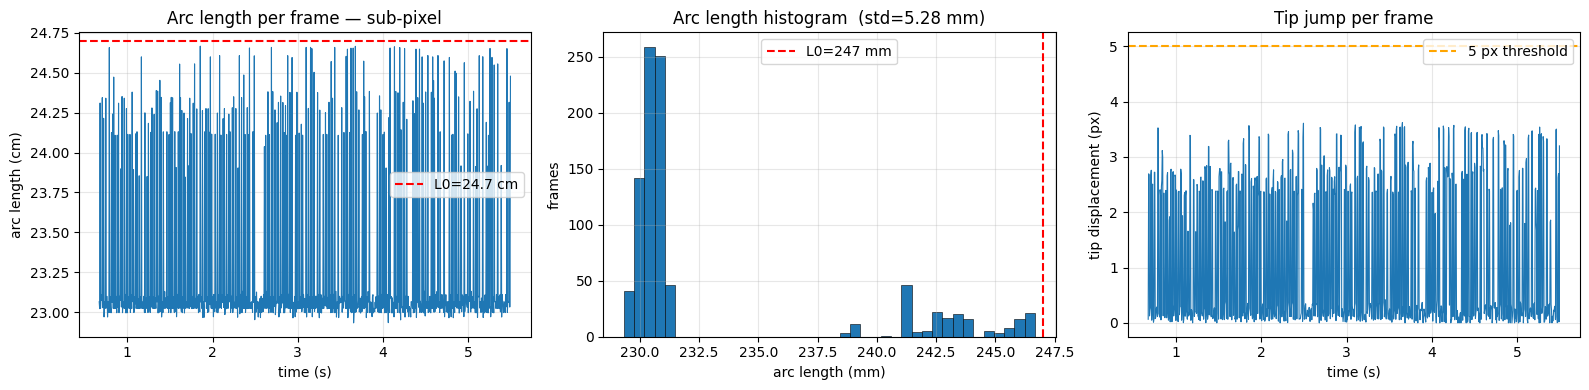

Saved arc CSV: ../../../Data/Real_data/arc_length_per_frame.csv


In [22]:
arc_arr  = np.array(arc_px)          # pixels
arc_m    = arc_arr / PIXELS_PER_METRE  # metres
t_frames = np.array(frame_idxs, dtype=float) / FPS

# Tip jump: frame-to-frame displacement of the last point
tips  = np.array([p[-1] for p in all_pts_px])   # (n, 2)
tip_jump = np.sqrt(np.sum(np.diff(tips, axis=0)**2, axis=1))

print('=== Arc-length statistics (sub-pixel pipeline) ===')
print(f'  mean  = {arc_m.mean()*100:.2f} cm  (expected ~{L0*100:.1f} cm)')
print(f'  std   = {arc_m.std()*1000:.2f} mm')
print(f'  range = {(arc_m.max()-arc_m.min())*1000:.2f} mm')
print(f'  min   = {arc_m.min()*100:.3f} cm   max = {arc_m.max()*100:.3f} cm')
print(f'\n  Tip jump (px): mean={tip_jump.mean():.2f}  std={tip_jump.std():.2f}  max={tip_jump.max():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=100)

axes[0].plot(t_frames, arc_m * 100, lw=0.8)
axes[0].axhline(L0 * 100, color='r', ls='--', label=f'L0={L0*100:.1f} cm')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('arc length (cm)')
axes[0].set_title('Arc length per frame — sub-pixel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(arc_m * 1000, bins=40, edgecolor='k', linewidth=0.4)
axes[1].axvline(L0 * 1000, color='r', ls='--', label=f'L0={L0*1000:.0f} mm')
axes[1].set_xlabel('arc length (mm)')
axes[1].set_ylabel('frames')
axes[1].set_title(f'Arc length histogram  (std={arc_m.std()*1000:.2f} mm)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_frames[1:], tip_jump, lw=0.8)
axes[2].axhline(5, color='orange', ls='--', label='5 px threshold')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('tip displacement (px)')
axes[2].set_title('Tip jump per frame')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save CSV for external analysis
np.savetxt(OUT_ARC_CSV,
           np.column_stack([frame_idxs, t_frames, arc_m]),
           header='frame_idx  time_s  arc_m', fmt='%d %.6f %.8f')
print(f'Saved arc CSV: {OUT_ARC_CSV}')

## Step 5b — Centreline overlay on raw video

Shows the sub-pixel centreline drawn on the actual raw video frames (not the mask).

- Green square = clamp (node 0)
- Red triangle = tip (last node)
- Red line = full centreline


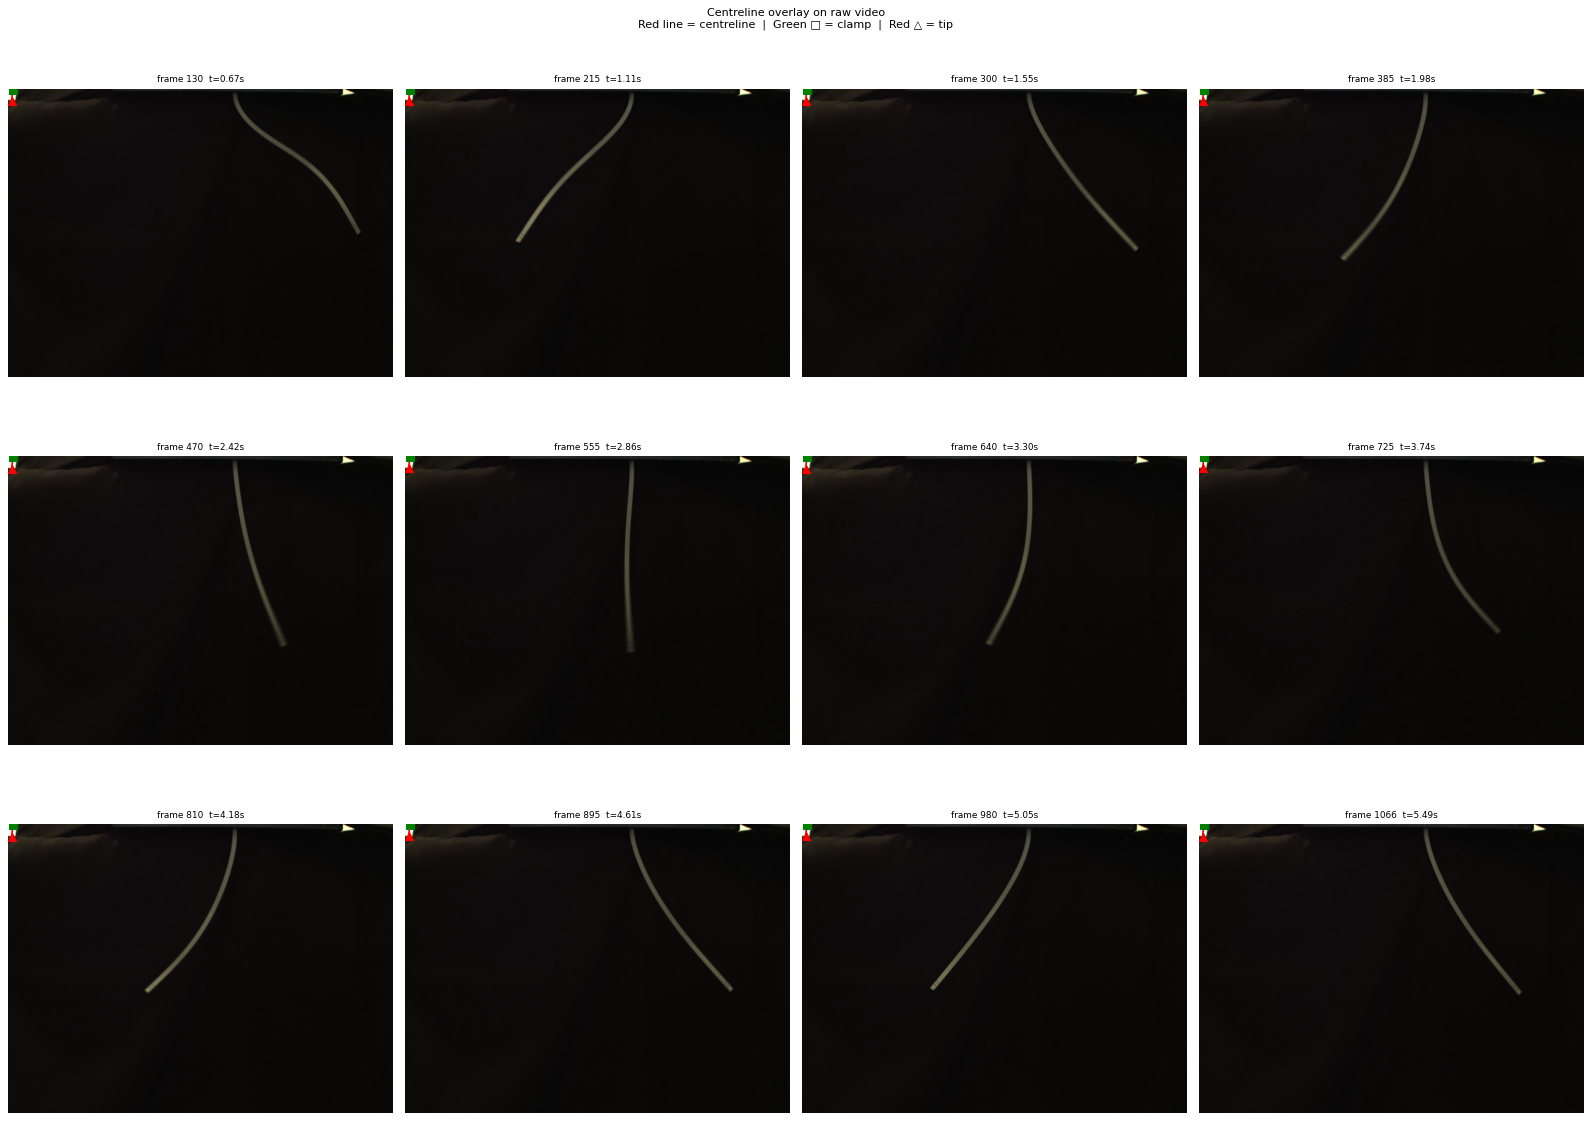

In [24]:
# Run after Step 3 and Step 4.
# Shows N_PREVIEW evenly-spaced frames from all_pts_px drawn on the raw video.

N_PREVIEW = 12   # number of frames to display

_cap, _tmp = _open_video(VIDEO_PATH)

_indices = np.linspace(0, len(all_pts_px) - 1, N_PREVIEW, dtype=int)
_n_cols  = 4
_n_rows  = int(np.ceil(N_PREVIEW / _n_cols))

fig, axes = plt.subplots(_n_rows, _n_cols, figsize=(20, _n_rows * 5), dpi=80)
axes = axes.flatten()

for _k, _ki in enumerate(_indices):
    _fi   = frame_idxs[_ki]
    _pts  = all_pts_px[_ki]          # (N_OUT, 2) [col, row] in full-frame px

    _cap.set(cv2.CAP_PROP_POS_FRAMES, _fi)
    _ret, _fr = _cap.read()
    _ax = axes[_k]
    if not _ret:
        _ax.set_visible(False)
        continue

    _ax.imshow(cv2.cvtColor(_fr, cv2.COLOR_BGR2RGB))
    _ax.plot(_pts[:, 0], _pts[:, 1], 'r-',  lw=1.5)
    _ax.plot(_pts[0, 0], _pts[0, 1], 'gs',  ms=7)   # clamp
    _ax.plot(_pts[-1,0], _pts[-1,1], 'r^',  ms=7)   # tip
    _ax.set_title(f'frame {_fi}  t={_fi/FPS:.2f}s', fontsize=8)
    _ax.axis('off')

for _k in range(len(_indices), len(axes)):
    axes[_k].set_visible(False)

_cap.release()
if _tmp: os.unlink(_tmp)

plt.suptitle(
    'Centreline overlay on raw video\n'
    'Red line = centreline  |  Green □ = clamp  |  Red △ = tip',
    fontsize=10)
plt.tight_layout()
plt.show()


## Step 6 — Convert to physical coordinates

Pixel → metres, flip y (image y increases downward, physical y upward),
anchor clamp to (0, 0).

Physical arc length: mean=22.88 cm  std=4.83 mm
  (expected ~24.7 cm)


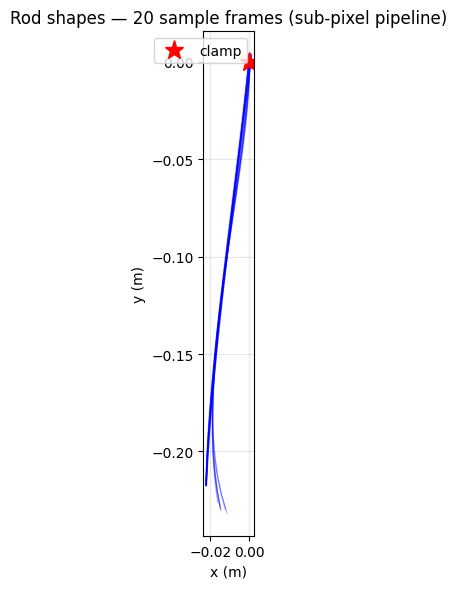

In [37]:
n_kept   = len(all_pts_px)
n_nodes  = N_OUT  # same as N+1 from MATLAB — we output N_OUT=25 points = N=24 segments
          # NOTE: if you need N+1=26 nodes (N=25 segs), change N_OUT in config to 26

# Convert pixel [col, row] → physical [x_m, y_m]
#   col → x  (rightward)    : x =  (col - clamp_col) / ppm
#   row → y  (upward)       : y = -(row - clamp_row) / ppm   (flip)
clamp_col, clamp_row = float(CLAMP_PX[0]), float(CLAMP_PX[1])

x_m = np.zeros((n_kept, n_nodes))   # (frames, N_OUT)
y_m = np.zeros((n_kept, n_nodes))

for _i, _lp in enumerate(all_pts_px):
    x_m[_i] = ( _lp[:, 0] - clamp_col) / PIXELS_PER_METRE
    y_m[_i] = -(_lp[:, 1] - clamp_row) / PIXELS_PER_METRE

# Enforce clamp at (0, 0)
x_m[:, 0] = 0.0
y_m[:, 0] = 0.0

# Arc-length in metres (cross-check)
arc_m2 = np.sqrt(np.diff(x_m, axis=1)**2 + np.diff(y_m, axis=1)**2).sum(axis=1)
print(f'Physical arc length: mean={arc_m2.mean()*100:.2f} cm  std={arc_m2.std()*1000:.2f} mm')
print(f'  (expected ~{L0*100:.1f} cm)')

# Plot 20 sample shapes
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
for _i in np.linspace(0, n_kept-1, 20, dtype=int):
    ax.plot(x_m[_i], y_m[_i], 'b', alpha=0.3, lw=1)
ax.plot(0, 0, 'r*', ms=14, label='clamp')
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Rod shapes — 20 sample frames (sub-pixel pipeline)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Compute θ, velocities, and momenta

Uses the same convention as `real_data_reconstruction.ipynb`:
- θ from `arctan2(dy, dx)` of consecutive node pairs
- ẋ, ẏ, θ̇ by `np.gradient` (central difference on the GP-smoothed positions)
- p_x = ρA·ẋ,  p_y = ρA·ẏ,  p_θ = ρI·θ̇

N=24  N_OUT=25  (N+1 nodes, N segments)
xdot   range: [-1.162, 2.082] m/s
ydot   range: [-3.004, 1.719] m/s
θdot   range: [-643.052, 1221.821] rad/s
p_x    range: [-4.1192e-02, 7.3792e-02]
p_y    range: [-1.0648e-01, 6.0934e-02]
p_θ    range: [-7.6586e-05, 1.4552e-04]


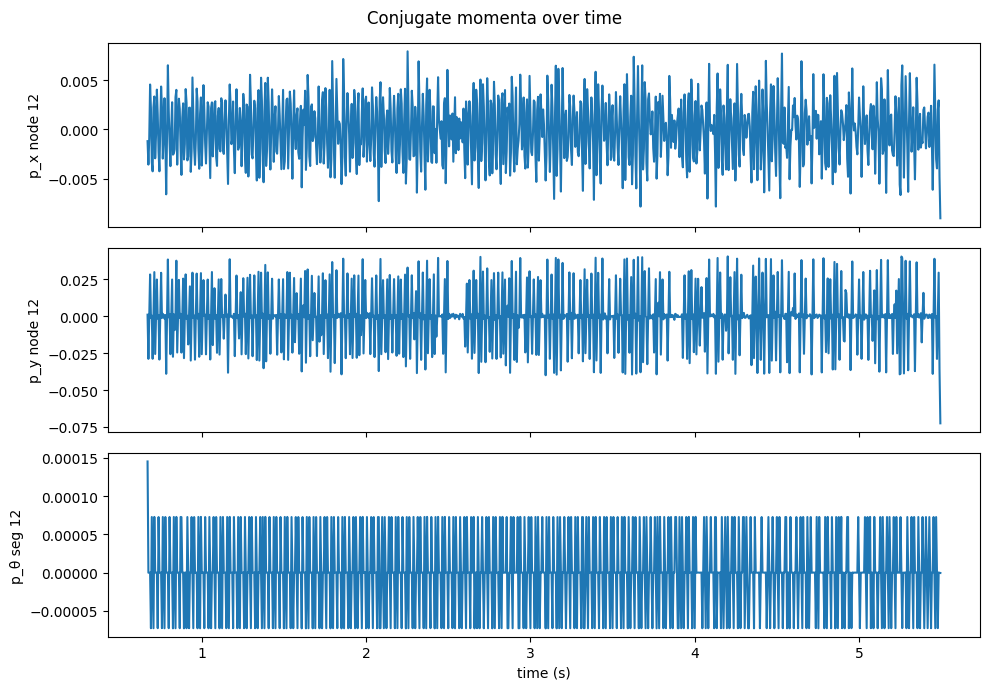

In [38]:
from scipy.signal import savgol_filter

dt = 1.0 / FPS
N  = N_OUT - 1   # number of segments  (N+1 nodes)

# ── θ: tangent angle of each segment ────────────────────────────────────────
dx_seg = np.diff(x_m, axis=1)   # (n_kept, N)
dy_seg = np.diff(y_m, axis=1)
theta  = np.arctan2(dy_seg, dx_seg)   # (n_kept, N)
for _i in range(n_kept):
    theta[_i] = np.unwrap(theta[_i])

# ── Velocities: np.gradient in time ─────────────────────────────────────────
xdot     = np.gradient(x_m,    dt, axis=0)   # (n_kept, N+1)
ydot     = np.gradient(y_m,    dt, axis=0)
thetadot = np.gradient(theta,  dt, axis=0)   # (n_kept, N)

# Enforce zero velocity at clamped base node
xdot[:, 0] = 0.0
ydot[:, 0] = 0.0

# ── Momenta ──────────────────────────────────────────────────────────────────
p_x     = rho * A * xdot        # (n_kept, N+1)
p_y     = rho * A * ydot
p_theta = rho * I * thetadot    # (n_kept, N)

p_x[:, 0]     = 0.0
p_y[:, 0]     = 0.0
p_theta[:, 0] = 0.0

print(f'N={N}  N_OUT={N_OUT}  (N+1 nodes, N segments)')
print(f'xdot   range: [{xdot.min():.3f}, {xdot.max():.3f}] m/s')
print(f'ydot   range: [{ydot.min():.3f}, {ydot.max():.3f}] m/s')
print(f'θdot   range: [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s')
print(f'p_x    range: [{p_x.min():.4e}, {p_x.max():.4e}]')
print(f'p_y    range: [{p_y.min():.4e}, {p_y.max():.4e}]')
print(f'p_θ    range: [{p_theta.min():.4e}, {p_theta.max():.4e}]')

# Quick plot
t_kept = np.array(frame_idxs, dtype=float) / FPS
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
_mid = N // 2
axes[0].plot(t_kept, p_x[:, _mid]); axes[0].set_ylabel(f'p_x node {_mid}')
axes[1].plot(t_kept, p_y[:, _mid]); axes[1].set_ylabel(f'p_y node {_mid}')
axes[2].plot(t_kept, p_theta[:, _mid]); axes[2].set_ylabel(f'p_θ seg {_mid}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Conjugate momenta over time')
plt.tight_layout()
plt.show()

## Step 8 — Assemble state matrix z and save

Layout matches `cosserat_GPR_pipeline_real_data.m`:
```
z = [x(N+1), y(N+1), θ(N), p_x(N+1), p_y(N+1), p_θ(N)]
```
Total columns = 4(N+1) + 2N = 6N+4.

In [ ]:
z = np.hstack([x_m, y_m, theta, p_x, p_y, p_theta])

expected_cols = 4*(N+1) + 2*N
assert z.shape == (n_kept, expected_cols), \
    f'z shape {z.shape} != expected ({n_kept}, {expected_cols})'

t_out = t_kept.reshape(-1, 1)

print(f'z shape: {z.shape}  (frames × state_dim={expected_cols})')
print(f't shape: {t_out.shape}  range [{t_out.min():.3f}, {t_out.max():.3f}] s')

# Boundary condition check
print(f'\n=== Boundary conditions ===')
print(f'max |x[:,0]|   = {np.abs(z[:,0]).max():.2e}   (expect 0)')
print(f'max |y[:,0]|   = {np.abs(z[:,N+1]).max():.2e}  (expect 0)')
print(f'max |p_x[:,0]| = {np.abs(z[:,2*(N+1)+N]).max():.2e}  (expect 0)')
print(f'max |p_y[:,0]| = {np.abs(z[:,3*(N+1)+N]).max():.2e}  (expect 0)')

os.makedirs(os.path.dirname(OUT_MAT), exist_ok=True)
savemat(OUT_MAT, {
    'z':   z,
    't':   t_out,
    'N':   float(N),
    'L0':  L0,
    'rho': rho,
    'A':   A,
    'I':   I,
    'fps': FPS,
    'pixels_per_metre': PIXELS_PER_METRE,
})
print(f'\nSaved: {OUT_MAT}')
print(f'  N={N}  L0={L0}  rho={rho}  A={A:.4e}  I={I:.4e}')

## Step 9 — Write annotated output video

Renders the original frames with the detected sub-pixel centreline overlaid.
Green line = centreline, green square = clamp (node 0), red triangle = tip.

In [ ]:
_cap, _tmp = _open_video(VIDEO_PATH)
_w = int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
_h = int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

_tmp_avi = OUT_VIDEO_H264.replace('.mp4', '_tmp.avi')
fourcc   = cv2.VideoWriter_fourcc(*'XVID')
_writer  = cv2.VideoWriter(_tmp_avi, fourcc, int(FPS), (_w, _h))

_lp_lookup = {frame_idxs[_i]: all_pts_px[_i] for _i in range(len(frame_idxs))}

_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
for _fi in range(frame_start, frame_end):
    _ret, _fr = _cap.read()
    if not _ret: break
    if _fi in _lp_lookup:
        _lp = _lp_lookup[_fi].astype(np.int32)
        cv2.polylines(_fr, [_lp.reshape(-1,1,2)], False, (0,255,0), 2, cv2.LINE_AA)
        cv2.circle(_fr, tuple(_lp[0]),  10, (0,200,0),  -1)
        cv2.circle(_fr, tuple(_lp[-1]), 10, (0,60,255), -1)
        # Draw every 4th node
        for _pt in _lp[::4]:
            cv2.circle(_fr, tuple(_pt), 4, (255,100,0), -1)
    _writer.write(_fr)

_cap.release()
_writer.release()
if _tmp: os.unlink(_tmp)

subprocess.run(['ffmpeg', '-y', '-i', _tmp_avi,
                '-c:v', 'libx264', '-pix_fmt', 'yuv420p', OUT_VIDEO_H264],
               capture_output=True)
os.unlink(_tmp_avi)
print(f'Saved: {OUT_VIDEO_H264}')

## Step 10 — Comparison: sub-pixel vs skeletonization arc-length

Load the arc-length CSV from the old pipeline (if available) and plot side-by-side.

In [ ]:
# Sub-pixel result (current pipeline)
arc_subpx_m = arc_arr / PIXELS_PER_METRE

print(f'Sub-pixel pipeline:')
print(f'  arc mean  = {arc_subpx_m.mean()*100:.3f} cm')
print(f'  arc std   = {arc_subpx_m.std()*1000:.3f} mm')
print(f'  arc range = {(arc_subpx_m.max()-arc_subpx_m.min())*1000:.3f} mm')

# Try to load old skeletonization result for comparison
_old_csv = OUT_ARC_CSV.replace('arc_length_per_frame', 'arc_length_skeleton_old')
if os.path.exists(_old_csv):
    _old = np.loadtxt(_old_csv)
    _old_arc_m = _old[:, 2]
    print(f'\nSkeletonization pipeline (old):')
    print(f'  arc mean  = {_old_arc_m.mean()*100:.3f} cm')
    print(f'  arc std   = {_old_arc_m.std()*1000:.3f} mm')
    print(f'  arc range = {(_old_arc_m.max()-_old_arc_m.min())*1000:.3f} mm')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    axes[0].plot(arc_subpx_m*100, lw=0.8, label=f'sub-pixel (std={arc_subpx_m.std()*1000:.1f}mm)')
    axes[0].plot(np.linspace(0, len(arc_subpx_m)-1, len(_old_arc_m)),
                 _old_arc_m*100, lw=0.8, alpha=0.7, label=f'skeleton (std={_old_arc_m.std()*1000:.1f}mm)')
    axes[0].axhline(L0*100, color='r', ls='--', label=f'L0={L0*100:.1f}cm')
    axes[0].set_ylabel('arc length (cm)'); axes[0].set_xlabel('frame')
    axes[0].set_title('Arc length over time'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].hist(arc_subpx_m*1000, bins=40, alpha=0.7, label='sub-pixel', edgecolor='k', lw=0.3)
    axes[1].hist(_old_arc_m*1000, bins=40, alpha=0.7, label='skeleton', edgecolor='k', lw=0.3)
    axes[1].axvline(L0*1000, color='r', ls='--')
    axes[1].set_xlabel('arc length (mm)'); axes[1].set_ylabel('frames')
    axes[1].set_title('Arc length histogram'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f'\nNo old pipeline CSV found at {_old_csv}')
    print('To compare, rename the skeleton pipeline CSV to that path and re-run this cell.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    axes[0].plot(t_frames, arc_subpx_m*100, lw=0.8)
    axes[0].axhline(L0*100, color='r', ls='--', label=f'L0={L0*100:.1f}cm')
    axes[0].set_ylabel('arc length (cm)'); axes[0].set_xlabel('time (s)')
    axes[0].set_title(f'Sub-pixel arc length  (std={arc_subpx_m.std()*1000:.2f}mm)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].hist(arc_subpx_m*1000, bins=40, edgecolor='k', lw=0.4)
    axes[1].axvline(L0*1000, color='r', ls='--')
    axes[1].set_xlabel('arc length (mm)'); axes[1].set_ylabel('frames')
    axes[1].set_title('Arc length histogram'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## Step 11 — 3D surface plots: x(t, node) and y(t, node)

In [ ]:
try:
    import plotly.graph_objects as go
    _has_plotly = True
except ImportError:
    _has_plotly = False
    print('plotly not installed — showing matplotlib heatmaps only')

_stride_t = max(1, n_kept // 200)
_t_ax     = t_frames[::_stride_t]
_s_ax     = np.linspace(0, L0, N_OUT)
_X        = x_m[::_stride_t, :]    # (n_t, N_OUT)
_Y        = y_m[::_stride_t, :]

if _has_plotly:
    for _Z, _cs, _lbl, _title in [
        (_X.T, 'RdBu',   'x (m)', 'x(s, t) — sub-pixel'),
        (_Y.T, 'plasma', 'y (m)', 'y(s, t) — sub-pixel'),
    ]:
        _kw = dict(cmid=0) if _cs == 'RdBu' else {}
        _fig = go.Figure(go.Surface(
            x=_t_ax, y=_s_ax, z=_Z,
            colorscale=_cs, colorbar=dict(title=_lbl), **_kw
        ))
        _fig.update_layout(
            title=_title,
            scene=dict(xaxis_title='time (s)', yaxis_title='arc s (m)', zaxis_title=_lbl,
                       camera=dict(eye=dict(x=1.8, y=-1.8, z=0.9))),
            width=750, height=500, margin=dict(l=0,r=0,t=40,b=0)
        )
        _fig.show()

# Matplotlib heatmaps (always shown)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
for _ax, _Z, _lbl in [(axes[0], _X.T, 'x (m)'), (axes[1], _Y.T, 'y (m)')]:
    _im = _ax.imshow(_Z, aspect='auto', origin='lower',
                     extent=[_t_ax[0], _t_ax[-1], 0, L0], cmap='plasma')
    plt.colorbar(_im, ax=_ax, label=_lbl)
    _ax.set_xlabel('time (s)'); _ax.set_ylabel('arc s (m)')
    _ax.set_title(f'{_lbl} heatmap — sub-pixel')
plt.tight_layout()
plt.show()